# **How Curvature, Dimensionality and Distributional Complexity Affect Riemannian Flow Matching**

## **Results**

- All helper utilities live in `visualize_run.py` (paths/globs, metrics I/O, and plotting).
- A run directory is expected to contain `artifacts/final_fixed_eval_outputs.pt` and `metrics.json`.

In [2]:
from visualize_run import get_metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Define output paths
- Specify output globs where outputs live

In [4]:
mog_paths = [
    '../outputs/runs/mog/euclidean/general/*',
    '../outputs/runs/mog/sphere/general/*',
    '../outputs/runs/mog/poincare/general/*',
]

gtg_paths = [
    '../outputs/runs/gtg/euclidean/general/*',
    '../outputs/runs/gtg/sphere/general/*',
    '../outputs/runs/gtg/poincare/general/*',
]

gaussian_ring_paths = [
    '../outputs/runs/general_fm/fm/*/*'
]

checkerboard_paths = [
    '../outputs/runs/checkerboard/euclidean/general/*',
    '../outputs/runs/checkerboard/sphere/general/*',
    '../outputs/runs/checkerboard/poincare/general/*',
]

### Load results
- Set visualize to True to save plots of final flow matching distribution.
- Results are saved to csv by default.
- Comment out ```get_method()``` lines to load results from csv.

In [5]:
# Load and save into csv (comment out if applicable)

#metrics_gtg = get_metrics([], gtg_paths, visualize=False, save=True, out_dir='runs/gtg')
# metrics_mog = get_metrics([], mog_paths, visualize=False, save=True, out_dir='runs/mog')
metrics_gaussian_ring = get_metrics([], gaussian_ring_paths, visualize=False, save=True, out_dir='runs/gaussian_ring')
# metrics_checkerboard = get_metrics([], checkerboard_paths, visualize=False, save=True, out_dir='runs/checkerboard')

# Retrieve from csv
metrics_gtg = pd.read_csv('runs/gtg/metrics.csv')
# metrics_mog = pd.read_csv('runs/mog/metrics.csv')
metrics_gaussian_ring = pd.read_csv('runs/gaussian_ring/metrics.csv')
# metrics_checkerboard = pd.read_csv('runs/checkerboard/metrics.csv')

SKIP (missing files):
  - missing artifacts file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/general_fm/fm/2026.05.21/162404/artifacts/final_fixed_eval_outputs.pt
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/general_fm/fm/2026.05.21/162404/metrics.json
SKIP (missing files):
  - missing artifacts file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/general_fm/fm/2026.05.21/162724/artifacts/final_fixed_eval_outputs.pt
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/general_fm/fm/2026.05.21/162724/metrics.json
SKIP (missing files):
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/general_fm/fm/2026.05.21/165832/metrics.json
SKIP (missing files):
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/

### Specify Results
- Change the experiment variable to applicable experiment
- change the x or y axis to get metrics

In [4]:
def print_metrics(experiment: pd.DataFrame, x: str, y: str):
    print(f"Available metrics:")
    print(", ".join(map(str, experiment.columns.tolist())))
    print()
    
    selected = experiment[[experiment.columns[0], x, y]]
    print(selected.to_string(index=False))

In [5]:
# metrics_gtg, metrics_mog, metrics_gaussian_ring, metrics_checkerboard
experiment = metrics_gtg
print_metrics(experiment, x='test_sample/volume_scaling_gap_target_minus_pred', y='test_sample/sinkhorn_knopp')

Available metrics:
Unnamed: 0, train/loss, train/loss_step, train/loss_epoch, nfe, integ_error, test/loss, test_vec/rfm_loss, test_vec/alignment, test_vec/finite_fraction, test_vec/norm_mean, test_vec/norm_max, test_vec/norm_std, test_vec/norm_p95, test_vec/tangency_violation_abs, test_vec/tangency_violation_rel, test_sample/sinkhorn_knopp, test_sample/tangent_sinkhorn_knopp, test_sample/tangent_to_geodesic_sinkhorn_ratio, test_sample/epsilon_coverage, test_sample/epsilon_precision, test_sample/frechet_variance_pred, test_sample/frechet_variance_target, test_sample/frechet_variance_ratio, test_sample/dispersion_predicted, test_sample/dispersion_target, test_sample/dispersion_ratio, test_sample/volume_scaling_mean_pred, test_sample/volume_scaling_mean_target, test_sample/volume_scaling_variance_pred, test_sample/volume_scaling_variance_target, test_sample/volume_scaling_gap_target_minus_pred, test_sample/volume_scaling_mean_start, test_sample/volume_scaling_variance_start, test_sample/v

In [6]:
# # average over seeds (manifold, curvature, dim are equal)
# experiment_avg = experiment.groupby(['manifold', 'dim', 'curvature'], as_index=False).mean(numeric_only=True)
# print(experiment_avg)

In [7]:
# # Convert ambient dimension to intrinsic dimension for sphere (dim - 1)
# experiment_avg_intr = experiment_avg.copy()
# experiment_avg_intr.loc[experiment_avg_intr['manifold'] == 'sphere', 'dim'] -= 1
# print(experiment_avg_intr)

### Plots RQ 1
**Main**

In [10]:
# # change all the VGG for sphere to negative
# experiment_avg_intr_vgg = experiment_avg_intr.copy()
# experiment_avg_intr_vgg.loc[experiment_avg_intr_vgg['manifold'] == 'sphere', 'test_sample/volume_scaling_gap_target_minus_pred'] *= 1

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# ============================================================
# User settings
# ============================================================

PERF_COL = "test_sample/sinkhorn_knopp"
VGG_COL = "test_sample/volume_scaling_gap_target_minus_pred"

DIM_COL = "dim"
MANIFOLD_COL = "manifold"
CURV_COL = "curvature"

EUCLIDEAN_NAME = "euclidean"
POINCARE_NAME = "poincare"
SPHERE_NAME = "sphere"

# In your metrics file, sphere dim often appears as ambient dim.
# Example: S^16 may be stored as dim=17.
SPHERE_DIM_MINUS_ONE = True

# Error bars: "sem" = standard error, "std" = standard deviation
ERROR_BAR = "sem"

# Whether to annotate Panel A points with dimension labels
LABEL_POINTS = True

# Curvature ordering:
# "abs"     = order by curvature magnitude, e.g. 0.01, 0.1, 1
# "numeric" = order by signed numeric value, e.g. -1, -0.1, 0.1, 1
CURVATURE_ORDER = "abs"


# ============================================================
# Helper functions
# ============================================================

def signed_log1p(x):
    """Signed log transform: keeps sign, handles zero, compresses large values."""
    return np.sign(x) * np.log10(1 + np.abs(x))


def error_value(x, kind="sem"):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()

    if len(x) <= 1:
        return 0.0

    if kind == "std":
        return x.std(ddof=1)

    if kind == "sem":
        return x.std(ddof=1) / np.sqrt(len(x))

    return 0.0


def nice_dim_label(x):
    if pd.isna(x):
        return ""
    if float(x).is_integer():
        return str(int(x))
    return f"{x:g}"


def nice_curv_label(x):
    if pd.isna(x):
        return "NA"
    try:
        return f"{float(x):g}"
    except Exception:
        return str(x)


def display_manifold_name(m):
    if m == POINCARE_NAME:
        return "Hyperbolic"
    if m == SPHERE_NAME:
        return "Spherical"
    if m == EUCLIDEAN_NAME:
        return "Euclidean"
    return str(m)


def ordered_curvatures(values, order="abs"):
    """
    Robust curvature ordering.

    order="abs":
        orders by curvature magnitude, useful when comparing negative
        hyperbolic and positive spherical curvatures.

    order="numeric":
        orders by signed numeric value.
    """
    values = pd.Series(values).dropna().unique()

    def sort_key(x):
        try:
            x_float = float(x)

            if order == "abs":
                return (abs(x_float), x_float)

            if order == "numeric":
                return (x_float,)

        except Exception:
            pass

        return (str(x),)

    return sorted(values, key=sort_key)


def ordered_manifolds(values):
    preferred_order = [POINCARE_NAME, SPHERE_NAME, EUCLIDEAN_NAME]
    values = list(pd.Series(values).dropna().unique())

    ordered = [m for m in preferred_order if m in values]
    ordered += [m for m in values if m not in ordered]

    return ordered


# ============================================================
# Data preparation
# ============================================================

def prepare_rq1_dataframe(df):
    """
    Adds:
    - compare_dim
    - Euclidean baselines per dimension
    - log relative performance wrt Euclidean
    - signed-log VGG gap wrt Euclidean
    """

    df = df.copy()

    df[PERF_COL] = pd.to_numeric(df[PERF_COL], errors="coerce")
    df[VGG_COL] = pd.to_numeric(df[VGG_COL], errors="coerce")
    df[DIM_COL] = pd.to_numeric(df[DIM_COL], errors="coerce")

    # Comparable dimension
    df["compare_dim"] = df[DIM_COL]

    if SPHERE_DIM_MINUS_ONE:
        is_sphere = df[MANIFOLD_COL].eq(SPHERE_NAME)
        df.loc[is_sphere, "compare_dim"] = df.loc[is_sphere, DIM_COL] - 1

    # Euclidean baseline per dimension
    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(
            euc_perf=(PERF_COL, "mean"),
            euc_vgg=(VGG_COL, "mean"),
        )
    )

    # Euclidean VGG is usually exactly zero.
    euc["euc_vgg"] = euc["euc_vgg"].fillna(0.0)

    df = df.merge(euc, on="compare_dim", how="left")

    # Relative RFM performance wrt Euclidean baseline
    df["rel_perf"] = df[PERF_COL] / df["euc_perf"]
    df["log_rel_perf"] = np.log10(df["rel_perf"])

    # VGG difference wrt Euclidean baseline
    # Ratio is avoided because Euclidean VGG is often exactly zero.
    df["vgg_gap_vs_euc"] = df[VGG_COL] - df["euc_vgg"]
    df["signed_log_vgg_gap"] = signed_log1p(df["vgg_gap_vs_euc"])

    return df


def summarize_for_curvature_plot(df_prepared):
    """
    Averages over seeds for each:
        dimension × manifold × curvature
    """

    plot_df = df_prepared[
        ~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)
    ].copy()

    group_cols = ["compare_dim", MANIFOLD_COL, CURV_COL]

    rows = []

    for keys, sub in plot_df.groupby(group_cols, dropna=False):
        compare_dim, manifold, curvature = keys

        row = {
            "compare_dim": compare_dim,
            MANIFOLD_COL: manifold,
            CURV_COL: curvature,
        }

        # Relative performance summary
        y = sub["log_rel_perf"].replace([np.inf, -np.inf], np.nan).dropna()
        row["log_rel_perf_mean"] = y.mean()
        row["log_rel_perf_err"] = error_value(y, ERROR_BAR)
        row["log_rel_perf_n"] = len(y)

        # VGG summary
        x = sub["signed_log_vgg_gap"].replace([np.inf, -np.inf], np.nan).dropna()
        row["signed_log_vgg_gap_mean"] = x.mean()
        row["signed_log_vgg_gap_err"] = error_value(x, ERROR_BAR)
        row["signed_log_vgg_gap_n"] = len(x)

        rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# Plotting
# ============================================================

def plot_rq1_three_panel_by_curvature(
    summary,
    title="RQ1 diagnostics: volume scaling and RFM performance by curvature",
):
    """
    Three panels:

    A. VGG gap vs relative performance
    B. Dimension vs relative performance
    C. Dimension vs VGG gap

    Points are means over seeds at fixed manifold, dimension, and curvature.
    Error bars show SEM or STD over seeds, depending on ERROR_BAR.
    """

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    marker_map = {
        POINCARE_NAME: "o",
        SPHERE_NAME: "+",
    }

    line_map = {
        POINCARE_NAME: "solid",
        SPHERE_NAME: "dashed",
    }

    manifolds = ordered_manifolds(summary[MANIFOLD_COL])
    curvatures = ordered_curvatures(summary[CURV_COL], order=CURVATURE_ORDER)

    # Ordered color map for curvatures
    cmap = plt.cm.viridis
    color_positions = np.linspace(0.15, 0.9, max(len(curvatures), 1))
    curvature_color_map = {
        c: cmap(color_positions[i])
        for i, c in enumerate(curvatures)
    }

    group_specs = []

    for manifold in manifolds:
        for curvature in curvatures:
            sub = summary[
                summary[MANIFOLD_COL].eq(manifold)
                & summary[CURV_COL].eq(curvature)
            ].copy()

            if sub.empty:
                continue

            group_specs.append({
                "sub": sub,
                "label": f"{display_manifold_name(manifold)}, c={nice_curv_label(curvature)}",
                "color": curvature_color_map[curvature],
                "marker": marker_map.get(manifold, "o"),
                "linestyle": line_map.get(manifold, "solid"),
            })

    # --------------------------------------------------------
    # Panel A: VGG gap vs relative performance
    # --------------------------------------------------------

    ax = axes[0]

    for spec in group_specs:
        sub = spec["sub"].dropna(
            subset=["signed_log_vgg_gap_mean", "log_rel_perf_mean"]
        )

        if sub.empty:
            continue

        ax.errorbar(
            sub["signed_log_vgg_gap_mean"],
            sub["log_rel_perf_mean"],
            xerr=sub["signed_log_vgg_gap_err"],
            yerr=sub["log_rel_perf_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linestyle="none",
            alpha=0.85,
            label=spec["label"],
        )

        if LABEL_POINTS:
            for _, row in sub.iterrows():
                ax.annotate(
                    nice_dim_label(row["compare_dim"]),
                    xy=(
                        row["signed_log_vgg_gap_mean"],
                        row["log_rel_perf_mean"],
                    ),
                    xytext=(5, 5),
                    textcoords="offset points",
                    fontsize=8,
                    alpha=0.85,
                )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    ax.set_title("A. Volume-gap vs relative performance")
    ax.set_xlabel(
        "Volume-growth gap vs Euclidean\n"
        "sgn(ΔVGG) · log10(1 + |ΔVGG|)"
    )
    ax.set_ylabel(
        "RFM performance vs Euclidean\n"
        "log10(Wasserstein / Euclidean)"
    )

    ax.text(
        0.02,
        0.02,
        "Point labels = dimension\nUndefined VGG omitted",
        transform=ax.transAxes,
        fontsize=9,
        va="bottom",
        ha="left",
    )

    # --------------------------------------------------------
    # Panel B: dimension vs relative performance
    # --------------------------------------------------------

    ax = axes[1]

    for spec in group_specs:
        sub = spec["sub"].dropna(
            subset=["compare_dim", "log_rel_perf_mean"]
        ).sort_values("compare_dim")

        if sub.empty:
            continue

        ax.errorbar(
            sub["compare_dim"],
            sub["log_rel_perf_mean"],
            yerr=sub["log_rel_perf_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.85,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    ax.set_xscale("log", base=2)
    ax.set_title("B. Relative performance across dimension")
    ax.set_xlabel("Dimension")
    ax.set_ylabel("log10(Wasserstein / Euclidean)")

    ax.text(
        0.02,
        0.02,
        "Above 0 = worse than Euclidean\nBelow 0 = better than Euclidean",
        transform=ax.transAxes,
        fontsize=9,
        va="bottom",
        ha="left",
    )

    # --------------------------------------------------------
    # Panel C: dimension vs VGG gap
    # --------------------------------------------------------

    ax = axes[2]

    for spec in group_specs:
        sub = spec["sub"].dropna(
            subset=["compare_dim", "signed_log_vgg_gap_mean"]
        ).sort_values("compare_dim")

        if sub.empty:
            continue

        ax.errorbar(
            sub["compare_dim"],
            sub["signed_log_vgg_gap_mean"],
            yerr=sub["signed_log_vgg_gap_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.85,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    ax.set_xscale("log", base=2)
    ax.set_title("C. Volume-growth gap across dimension")
    ax.set_xlabel("Dimension")
    ax.set_ylabel("sgn(ΔVGG) · log10(1 + |ΔVGG|)")

    ax.text(
        0.02,
        0.02,
        "Euclidean baseline is 0\nUndefined VGG omitted",
        transform=ax.transAxes,
        fontsize=9,
        va="bottom",
        ha="left",
    )

    # --------------------------------------------------------
    # Shared formatting
    # --------------------------------------------------------

    dims = sorted(summary["compare_dim"].dropna().unique())

    for ax in axes[1:]:
        ax.set_xticks(dims)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

    for ax in axes:
        ax.grid(alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
    )

    fig.suptitle(title, fontsize=15, y=1.03)

    fig.text(
        0.01,
        -0.03,
        (
            f"Points are means over seeds at fixed manifold, dimension, and curvature. "
            f"Error bars show {ERROR_BAR.upper()} over seeds. "
            f"Curvatures ordered by {CURVATURE_ORDER}."
        ),
        fontsize=9,
        ha="left",
        va="top",
    )

    fig.tight_layout()

    return fig, axes

In [10]:
def make_main_data_story_table(df_prepared):
    """
    Creates a table like:

    Dimension | Poincaré vs Euclidean | Sphere vs Euclidean

    Values are multiplicative relative Wasserstein distances:
        >1 means worse than Euclidean
        <1 means better than Euclidean

    Curvatures and seeds are pooled per manifold/dimension.
    """

    plot_df = df_prepared[
        ~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)
    ].copy()

    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=["compare_dim", MANIFOLD_COL, "log_rel_perf"])

    rows = []

    for (dim, manifold), sub in plot_df.groupby(["compare_dim", MANIFOLD_COL]):
        # Use the same log-space averaging as the plots
        log_mean = sub["log_rel_perf"].mean()
        log_sem = sub["log_rel_perf"].std(ddof=1) / np.sqrt(len(sub)) if len(sub) > 1 else 0.0

        factor = 10 ** log_mean
        lower = 10 ** (log_mean - log_sem)
        upper = 10 ** (log_mean + log_sem)

        rows.append({
            "Dimension": int(dim) if float(dim).is_integer() else dim,
            "Manifold": manifold,
            "Relative factor": factor,
            "Lower": lower,
            "Upper": upper,
            "n": len(sub),
        })

    long_table = pd.DataFrame(rows)

    def format_factor(row):
        factor = row["Relative factor"]
        lower = row["Lower"]
        upper = row["Upper"]

        if factor > 1:
            direction = "worse"
        elif factor < 1:
            direction = "better"
        else:
            direction = "same"

        return f"{factor:.2g}× {direction} [{lower:.2g}, {upper:.2g}]"

    long_table["Formatted"] = long_table.apply(format_factor, axis=1)

    wide_table = (
        long_table
        .pivot(index="Dimension", columns="Manifold", values="Formatted")
        .reset_index()
        .sort_values("Dimension")
    )

    # Rename columns for paper-friendly table
    rename_map = {
        POINCARE_NAME: "Poincaré vs Euclidean",
        SPHERE_NAME: "Sphere vs Euclidean",
    }

    wide_table = wide_table.rename(columns=rename_map)

    # Keep only the desired columns if they exist
    desired_cols = [
        "Dimension",
        "Poincaré vs Euclidean",
        "Sphere vs Euclidean",
    ]

    wide_table = wide_table[
        [col for col in desired_cols if col in wide_table.columns]
    ]

    return wide_table, long_table

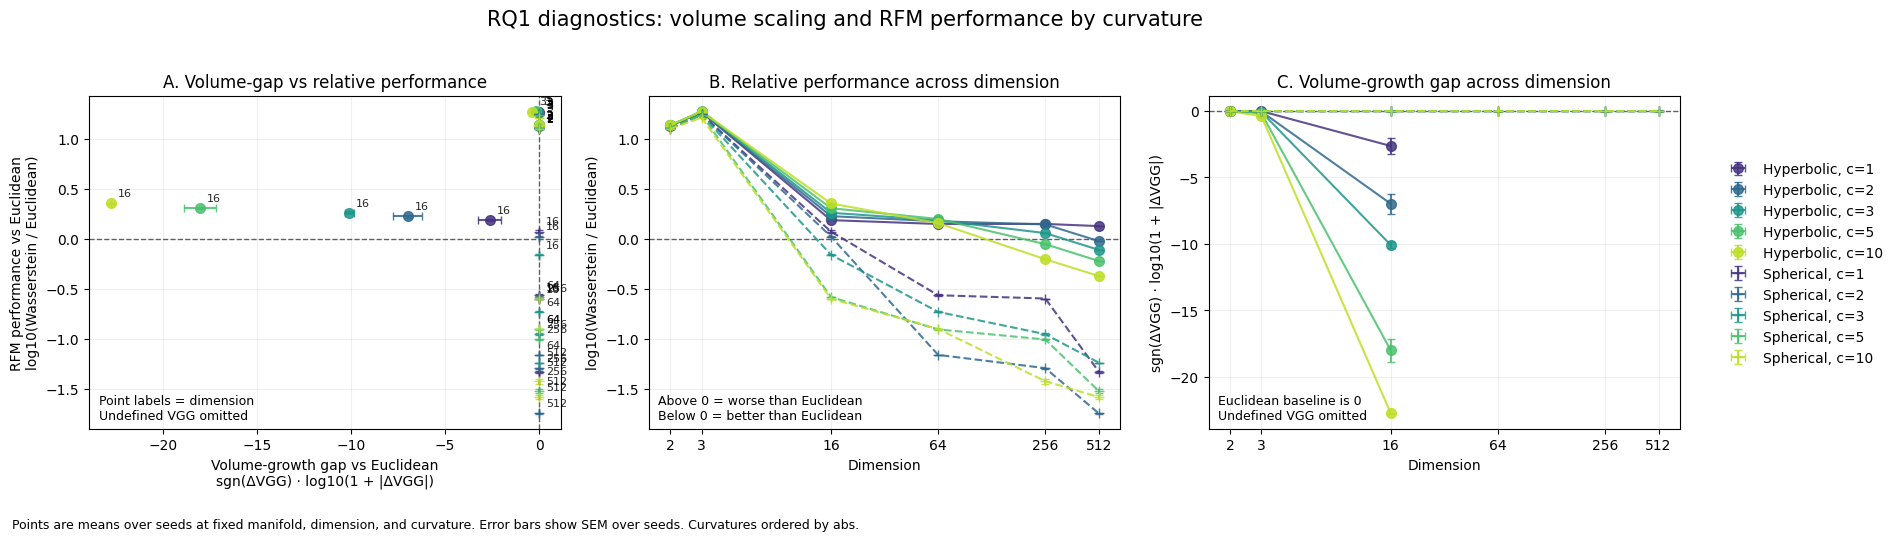

Manifold,Dimension,Poincaré vs Euclidean,Sphere vs Euclidean
0,2,"14× worse [14, 14]","13× worse [13, 13]"
1,3,"19× worse [19, 19]","17× worse [17, 17]"
2,16,"1.8× worse [1.8, 1.9]","0.56× better [0.47, 0.67]"
3,64,"1.5× worse [1.5, 1.5]","0.14× better [0.12, 0.16]"
4,256,"1× worse [0.96, 1.1]","0.088× better [0.074, 0.11]"
5,512,"0.76× better [0.68, 0.84]","0.033× better [0.029, 0.037]"


In [11]:
rq1_prepared = prepare_rq1_dataframe(experiment)
summary_by_curvature = summarize_for_curvature_plot(rq1_prepared)

fig, axes = plot_rq1_three_panel_by_curvature(summary_by_curvature)
plt.show()

main_story_table, main_story_long = make_main_data_story_table(rq1_prepared)
display(main_story_table)

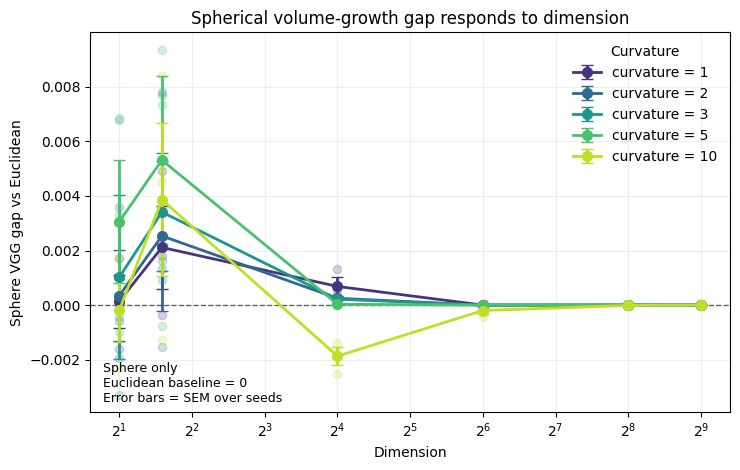

In [12]:
def plot_sphere_vgg_by_curvature(df_prepared, use_signed_log=False):
    """
    Sphere-only plot of VGG vs dimension, with separate lines per curvature.

    Shows:
    - faint points = individual seeds/runs
    - line + markers = mean per dimension/curvature
    - error bars = SEM over seeds
    """

    sphere_df = df_prepared[
        df_prepared[MANIFOLD_COL].eq(SPHERE_NAME)
    ].copy()

    sphere_df = sphere_df.replace([np.inf, -np.inf], np.nan)

    if use_signed_log:
        y_col = "signed_log_vgg_gap"
        y_label = "sgn(ΔVGG) · log10(1 + |ΔVGG|)"
        title = "Spherical volume-growth gap responds to dimension"
    else:
        y_col = "vgg_gap_vs_euc"
        y_label = "Sphere VGG gap vs Euclidean"
        title = "Spherical volume-growth gap responds to dimension"

    sphere_df = sphere_df.dropna(subset=["compare_dim", CURV_COL, y_col])

    summary = (
        sphere_df
        .groupby(["compare_dim", CURV_COL], as_index=False)
        .agg(
            y_mean=(y_col, "mean"),
            y_std=(y_col, "std"),
            y_n=(y_col, "count"),
        )
    )

    summary["y_sem"] = summary["y_std"] / np.sqrt(summary["y_n"])
    summary["y_sem"] = summary["y_sem"].fillna(0.0)
    summary = summary.sort_values(["curvature", "compare_dim"])

    curvatures = sorted(summary[CURV_COL].dropna().unique())

    cmap = plt.cm.viridis
    color_values = np.linspace(0.15, 0.9, len(curvatures))
    curvature_colors = {
        c: cmap(color_values[i])
        for i, c in enumerate(curvatures)
    }

    fig, ax = plt.subplots(figsize=(7.5, 4.8))

    for curvature in curvatures:
        raw_sub = sphere_df[sphere_df[CURV_COL].eq(curvature)]
        sum_sub = summary[summary[CURV_COL].eq(curvature)]

        color = curvature_colors[curvature]

        # Individual seeds/runs
        ax.scatter(
            raw_sub["compare_dim"],
            raw_sub[y_col],
            color=color,
            alpha=0.22,
            s=35,
        )

        # Mean ± SEM line
        ax.errorbar(
            sum_sub["compare_dim"],
            sum_sub["y_mean"],
            yerr=sum_sub["y_sem"],
            fmt="o-",
            color=color,
            markersize=7,
            capsize=4,
            linewidth=2,
            label=f"curvature = {nice_curv_label(curvature)}",
        )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    ax.set_xscale("log", base=2)

    ax.set_xlabel("Dimension")
    ax.set_ylabel(y_label)
    ax.set_title(title)

    ax.text(
        0.02,
        0.02,
        "Sphere only\nEuclidean baseline = 0\nError bars = SEM over seeds",
        transform=ax.transAxes,
        fontsize=9,
        va="bottom",
        ha="left",
    )

    ax.grid(alpha=0.2)
    ax.legend(frameon=False, title="Curvature")

    fig.tight_layout()

    return fig, ax, summary

fig, ax, summary = plot_sphere_vgg_by_curvature(rq1_prepared, use_signed_log=False)

**Appendix**

In [13]:
# ============================================================
# Extra metric columns
# ============================================================

FRECHET_VAR_COL = "test_sample/frechet_variance_pred"
FRECHET_VAR_TARGET_COL = "test_sample/frechet_variance_target"
FRECHET_VAR_RATIO_COL = "test_sample/frechet_variance_ratio"

RADIUS_COL = "radius_x1"


# ============================================================
# General helpers
# ============================================================

def ordered_values_numeric(values, use_abs=False):
    values = pd.Series(values).dropna().unique()

    def sort_key(x):
        try:
            x = float(x)
            if use_abs:
                return (abs(x), x)
            return (x,)
        except Exception:
            return (str(x),)

    return sorted(values, key=sort_key)


def safe_log10(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.log10(x.where(x > 0))


def mean_sem(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()

    if len(x) == 0:
        return np.nan, np.nan, 0

    mean = x.mean()

    if len(x) == 1:
        return mean, 0.0, 1

    sem = x.std(ddof=1) / np.sqrt(len(x))
    return mean, sem, len(x)


def add_relative_to_euclidean(df_prepared, metric_col, out_col):
    """
    Adds metric / Euclidean metric at the same comparable dimension.

    Useful for Wasserstein and Fréchet variance if you want a fair
    comparison across dimension.
    """

    df = df_prepared.copy()

    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(euc_metric=(metric_col, "mean"))
    )

    df = df.merge(euc, on="compare_dim", how="left")
    df[out_col] = df[metric_col] / df["euc_metric"]

    return df

In [24]:
def make_curvature_dimension_surface(
    df_prepared,
    metric_col,
    value_col_name="value",
    relative_to_euclidean=False,
    log10_value=False,
    signed_log_value=False,
    exclude_euclidean=True,
):
    """
    Creates a summarized dataframe for heatmaps.

    Each cell is:
        mean metric over seeds
        for a given manifold × curvature × dimension.

    Options:
    - relative_to_euclidean:
        metric / Euclidean metric at same dimension
    - log10_value:
        log10 of the plotted value
    - signed_log_value:
        sign(x) * log10(1 + |x|)
    """

    df = df_prepared.copy()

    df[metric_col] = pd.to_numeric(df[metric_col], errors="coerce")

    if relative_to_euclidean:
        rel_col = f"{metric_col}_relative_to_euclidean"
        df = add_relative_to_euclidean(df, metric_col, rel_col)
        base_col = rel_col
    else:
        base_col = metric_col

    if log10_value:
        df[value_col_name] = safe_log10(df[base_col])
    elif signed_log_value:
        df[value_col_name] = signed_log1p(df[base_col])
    else:
        df[value_col_name] = df[base_col]

    if exclude_euclidean:
        df = df[~df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()

    rows = []

    for keys, sub in df.groupby([MANIFOLD_COL, CURV_COL, "compare_dim"], dropna=False):
        manifold, curvature, dim = keys

        mean, sem, n = mean_sem(sub[value_col_name])

        rows.append({
            MANIFOLD_COL: manifold,
            CURV_COL: curvature,
            "compare_dim": dim,
            "mean": mean,
            "sem": sem,
            "n": n,
        })

    return pd.DataFrame(rows)


def plot_curvature_dimension_heatmaps(
    surface_df,
    title,
    cbar_label,
    manifolds=(POINCARE_NAME, SPHERE_NAME),
    annotate=True,
    cmap="viridis",
    curvature_order_abs=True,
):
    """
    Plots one heatmap per manifold.

    x-axis: dimension
    y-axis: curvature
    color: metric surface value
    """

    manifolds = [m for m in manifolds if m in surface_df[MANIFOLD_COL].unique()]

    fig, axes = plt.subplots(
        1,
        len(manifolds),
        figsize=(6.2 * len(manifolds), 4.8),
        squeeze=False,
    )

    axes = axes[0]

    # Shared color scale across manifolds
    values = surface_df["mean"].replace([np.inf, -np.inf], np.nan)
    vmin = values.min()
    vmax = values.max()

    for ax, manifold in zip(axes, manifolds):
        sub = surface_df[surface_df[MANIFOLD_COL].eq(manifold)].copy()

        dims = ordered_values_numeric(sub["compare_dim"])
        curvatures = ordered_values_numeric(
            sub[CURV_COL],
            use_abs=curvature_order_abs,
        )

        pivot = (
            sub.pivot_table(
                index=CURV_COL,
                columns="compare_dim",
                values="mean",
                aggfunc="mean",
            )
            .reindex(index=curvatures, columns=dims)
        )

        im = ax.imshow(
            pivot.values,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="gaussian",
        )

        ax.set_title(display_manifold_name(manifold))
        ax.set_xlabel("Dimension")
        ax.set_ylabel("Curvature")

        ax.set_xticks(np.arange(len(dims)))
        ax.set_xticklabels([nice_dim_label(d) for d in dims], rotation=45)

        ax.set_yticks(np.arange(len(curvatures)))
        ax.set_yticklabels([nice_curv_label(c) for c in curvatures])

        if annotate:
            for i in range(len(curvatures)):
                for j in range(len(dims)):
                    val = pivot.values[i, j]
                    if pd.notna(val):
                        ax.text(
                            j,
                            i,
                            f"{val:.2g}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

    fig.suptitle(title, fontsize=15, y=1.04)

    cbar = fig.colorbar(im, ax=axes, shrink=0.85)
    cbar.set_label(cbar_label)


    return fig, axes

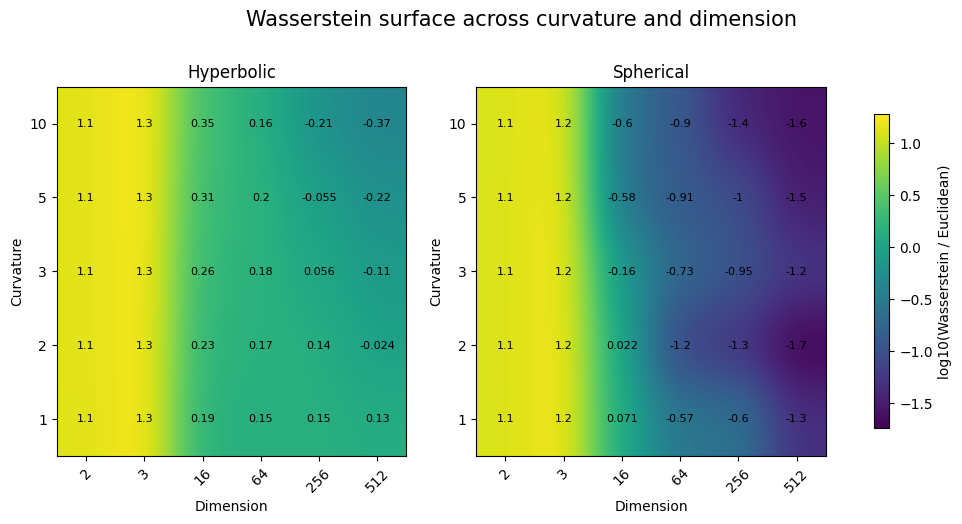

In [25]:
def plot_wasserstein_heatmaps(df_prepared):
    surface = make_curvature_dimension_surface(
        df_prepared,
        metric_col=PERF_COL,
        value_col_name="log_rel_wasserstein",
        relative_to_euclidean=True,
        log10_value=True,
    )

    fig, axes = plot_curvature_dimension_heatmaps(
        surface,
        title="Wasserstein surface across curvature and dimension",
        cbar_label="log10(Wasserstein / Euclidean)",
        annotate=True,
    )

    return fig, axes, surface


fig_wass, axes_wass, wasserstein_surface = plot_wasserstein_heatmaps(rq1_prepared)
plt.show()

# Optional:
# fig_wass.savefig("rq1_heatmap_wasserstein_surface.png", dpi=300, bbox_inches="tight")
# wasserstein_surface.to_csv("rq1_heatmap_wasserstein_surface.csv", index=False)

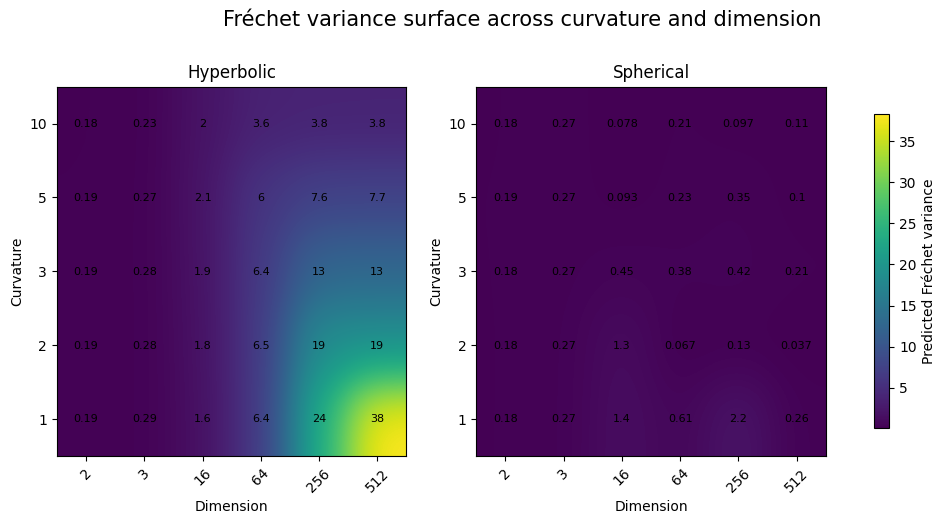

In [26]:
def plot_frechet_variance_heatmaps(df_prepared, relative_to_euclidean=False):
    surface = make_curvature_dimension_surface(
        df_prepared,
        metric_col=FRECHET_VAR_COL,
        value_col_name="frechet_variance_surface",
        relative_to_euclidean=relative_to_euclidean,
        log10_value=relative_to_euclidean,
    )

    if relative_to_euclidean:
        cbar_label = "log10(Fréchet variance / Euclidean)"
        title = "Relative Fréchet variance surface across curvature and dimension"
    else:
        cbar_label = "Predicted Fréchet variance"
        title = "Fréchet variance surface across curvature and dimension"

    fig, axes = plot_curvature_dimension_heatmaps(
        surface,
        title=title,
        cbar_label=cbar_label,
        annotate=True,
    )

    return fig, axes, surface


fig_fvar, axes_fvar, frechet_variance_surface = plot_frechet_variance_heatmaps(
    rq1_prepared,
    relative_to_euclidean=False,
)

plt.show()

# Optional:
# fig_fvar.savefig("rq1_heatmap_frechet_variance_surface.png", dpi=300, bbox_inches="tight")

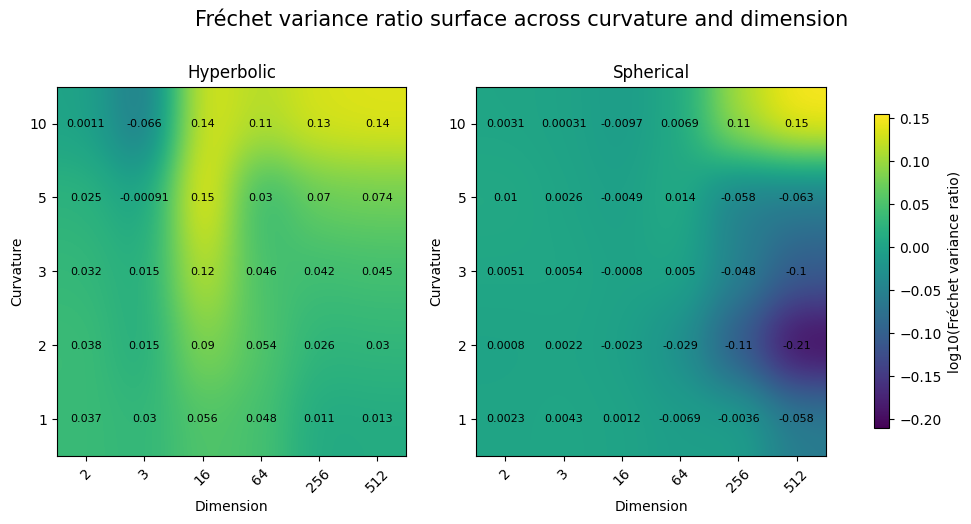

In [27]:
def plot_frechet_variance_ratio_heatmaps(df_prepared, log10_ratio=True):
    surface = make_curvature_dimension_surface(
        df_prepared,
        metric_col=FRECHET_VAR_RATIO_COL,
        value_col_name="frechet_variance_ratio_surface",
        relative_to_euclidean=False,
        log10_value=log10_ratio,
    )

    if log10_ratio:
        cbar_label = "log10(Fréchet variance ratio)"
        title = "Fréchet variance ratio surface across curvature and dimension"
    else:
        cbar_label = "Fréchet variance ratio"
        title = "Fréchet variance ratio surface across curvature and dimension"

    fig, axes = plot_curvature_dimension_heatmaps(
        surface,
        title=title,
        cbar_label=cbar_label,
        annotate=True,
    )

    return fig, axes, surface


fig_fvar_ratio, axes_fvar_ratio, frechet_variance_ratio_surface = (
    plot_frechet_variance_ratio_heatmaps(
        rq1_prepared,
        log10_ratio=True,
    )
)

plt.show()

# Optional:
# fig_fvar_ratio.savefig("rq1_heatmap_frechet_variance_ratio_surface.png", dpi=300, bbox_inches="tight")

In [28]:
def make_spearman_vgg_wasserstein_table(df_prepared):
    """
    Spearman correlations between VGG and Wasserstein.

    Uses experiment means:
        dimension × manifold × curvature

    Reports both:
    - raw VGG vs raw Wasserstein
    - signed-log VGG vs log-relative Wasserstein
    """

    plot_df = df_prepared[
        ~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)
    ].copy()

    grouped = (
        plot_df
        .groupby(["compare_dim", MANIFOLD_COL, CURV_COL], as_index=False)
        .agg(
            wasserstein=(PERF_COL, "mean"),
            log_rel_wasserstein=("log_rel_perf", "mean"),
            vgg=("vgg_gap_vs_euc", "mean"),
            signed_log_vgg=("signed_log_vgg_gap", "mean"),
            n_seeds=(PERF_COL, "count"),
        )
    )

    rows = []

    subsets = [("All non-Euclidean", grouped)]

    for manifold in ordered_manifolds(grouped[MANIFOLD_COL]):
        sub = grouped[grouped[MANIFOLD_COL].eq(manifold)]
        subsets.append((display_manifold_name(manifold), sub))

    for label, sub in subsets:
        sub = sub.replace([np.inf, -np.inf], np.nan)

        raw = sub[["vgg", "wasserstein"]].dropna()
        transformed = sub[["signed_log_vgg", "log_rel_wasserstein"]].dropna()

        raw_rho = (
            raw["vgg"].corr(raw["wasserstein"], method="spearman")
            if len(raw) >= 3 else np.nan
        )

        transformed_rho = (
            transformed["signed_log_vgg"].corr(
                transformed["log_rel_wasserstein"],
                method="spearman",
            )
            if len(transformed) >= 3 else np.nan
        )

        rows.append({
            "Subset": label,
            "n experiments": len(sub),
            "Spearman rho: raw VGG vs raw Wasserstein": raw_rho,
            "Spearman rho: signed-log VGG vs log-relative Wasserstein": transformed_rho,
        })

    table = pd.DataFrame(rows)

    return table, grouped


spearman_table, spearman_experiment_means = make_spearman_vgg_wasserstein_table(
    rq1_prepared
)

display(spearman_table)

# Optional:
# spearman_table.to_csv("rq1_spearman_vgg_wasserstein_table.csv", index=False)
# spearman_experiment_means.to_csv("rq1_spearman_experiment_means.csv", index=False)

,Subset,n experiments,Spearman rho: raw VGG vs raw Wasserstein,Spearman rho: signed-log VGG vs log-relative Wasserstein
0,All non-Euclidean,60,-0.273659,-0.102649
1,Hyperbolic,30,-0.932143,0.407143
2,Spherical,30,0.040494,0.732028


In [ ]:
def plot_gaussian_ring_radius_vgg_wasserstein(
    ring_df,
    use_log_relative_wasserstein=True,
    manifold=None,
):
    """
    Appendix plot for Gaussian ring experiments.

    Panel A:
        radius vs VGG

    Panel B:
        radius vs Wasserstein

    Lines are drawn separately for each manifold × dimension × curvature.
    """

    if manifold is not None:
        ring_df = ring_df[ring_df[MANIFOLD_COL].eq(manifold)].copy()

    if ring_df.empty:
        print("No rows left after filtering.")
        return None, None, pd.DataFrame()

    y_wass_col = np.log(ring_df[PERF_COL]) if use_log_relative_wasserstein else PERF_COL

    grouped = (
        ring_df
        .groupby([MANIFOLD_COL, "dim", CURV_COL, RADIUS_COL], as_index=False)
        .agg(
            vgg_mean=("test_sample/volume_scaling_gap_target_minus_pred", "mean"),
            vgg_sem=("test_sample/volume_scaling_gap_target_minus_pred", lambda x: mean_sem(x)[1]),
            wass_mean=(y_wass_col, "mean"),
            wass_sem=(y_wass_col, lambda x: mean_sem(x)[1]),
            n=(PERF_COL, "count"),
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    manifolds = ordered_manifolds(grouped[MANIFOLD_COL])
    dims = ordered_values_numeric(grouped["dim"])
    curvatures = ordered_values_numeric(grouped[CURV_COL], use_abs=True)

    cmap = plt.cm.viridis
    color_positions = np.linspace(0.15, 0.9, max(len(dims), 1))
    dim_colors = {
        d: cmap(color_positions[i])
        for i, d in enumerate(dims)
    }

    marker_map = {
        POINCARE_NAME: "o",
        SPHERE_NAME: "s",
    }

    line_map = {
        POINCARE_NAME: "solid",
        SPHERE_NAME: "dashed",
    }

    for manifold_name in manifolds:
        for dim in dims:
            for curvature in curvatures:
                sub = grouped[
                    grouped[MANIFOLD_COL].eq(manifold_name)
                    & grouped["dim"].eq(dim)
                    & grouped[CURV_COL].eq(curvature)
                ].sort_values(RADIUS_COL)

                if sub.empty:
                    continue

                label = (
                    f"{display_manifold_name(manifold_name)}, "
                    f"d={nice_dim_label(dim)}, "
                    f"c={nice_curv_label(curvature)}"
                )

                color = dim_colors[dim]
                marker = marker_map.get(manifold_name, "o")
                linestyle = line_map.get(manifold_name, "solid")

                axes[0].errorbar(
                    sub[RADIUS_COL],
                    sub["vgg_mean"],
                    yerr=sub["vgg_sem"],
                    fmt=marker,
                    linestyle=linestyle,
                    color=color,
                    capsize=3,
                    alpha=0.85,
                    label=label,
                )

                axes[1].errorbar(
                    sub[RADIUS_COL],
                    sub["wass_mean"],
                    yerr=sub["wass_sem"],
                    fmt=marker,
                    linestyle=linestyle,
                    color=color,
                    capsize=3,
                    alpha=0.85,
                )

    axes[0].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)

    axes[0].set_title("A. Radius vs volume-growth gap")
    axes[0].set_xlabel("Gaussian ring radius")
    axes[0].set_ylabel("sgn(ΔVGG) · log10(1 + |ΔVGG|)")

    axes[1].set_title("B. Radius vs Wasserstein performance")
    axes[1].set_xlabel("Gaussian ring radius")

    if use_log_relative_wasserstein:
        axes[1].set_ylabel("log10(Wasserstein / Euclidean)")
    else:
        axes[1].set_ylabel("Wasserstein")

    for ax in axes:
        ax.grid(alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        fontsize=8,
    )

    fig.suptitle("Gaussian ring: radius dependence of VGG and RFM performance", y=1.03)
    fig.tight_layout()

    return fig, axes, grouped

In [37]:
plot_gaussian_ring_radius_vgg_wasserstein(metrics_gaussian_ring)

KeyError: "Column(s) ['log_rel_perf'] do not exist"